Total points in full dataset: 6961
Points after filtering for Astroviridae: 681


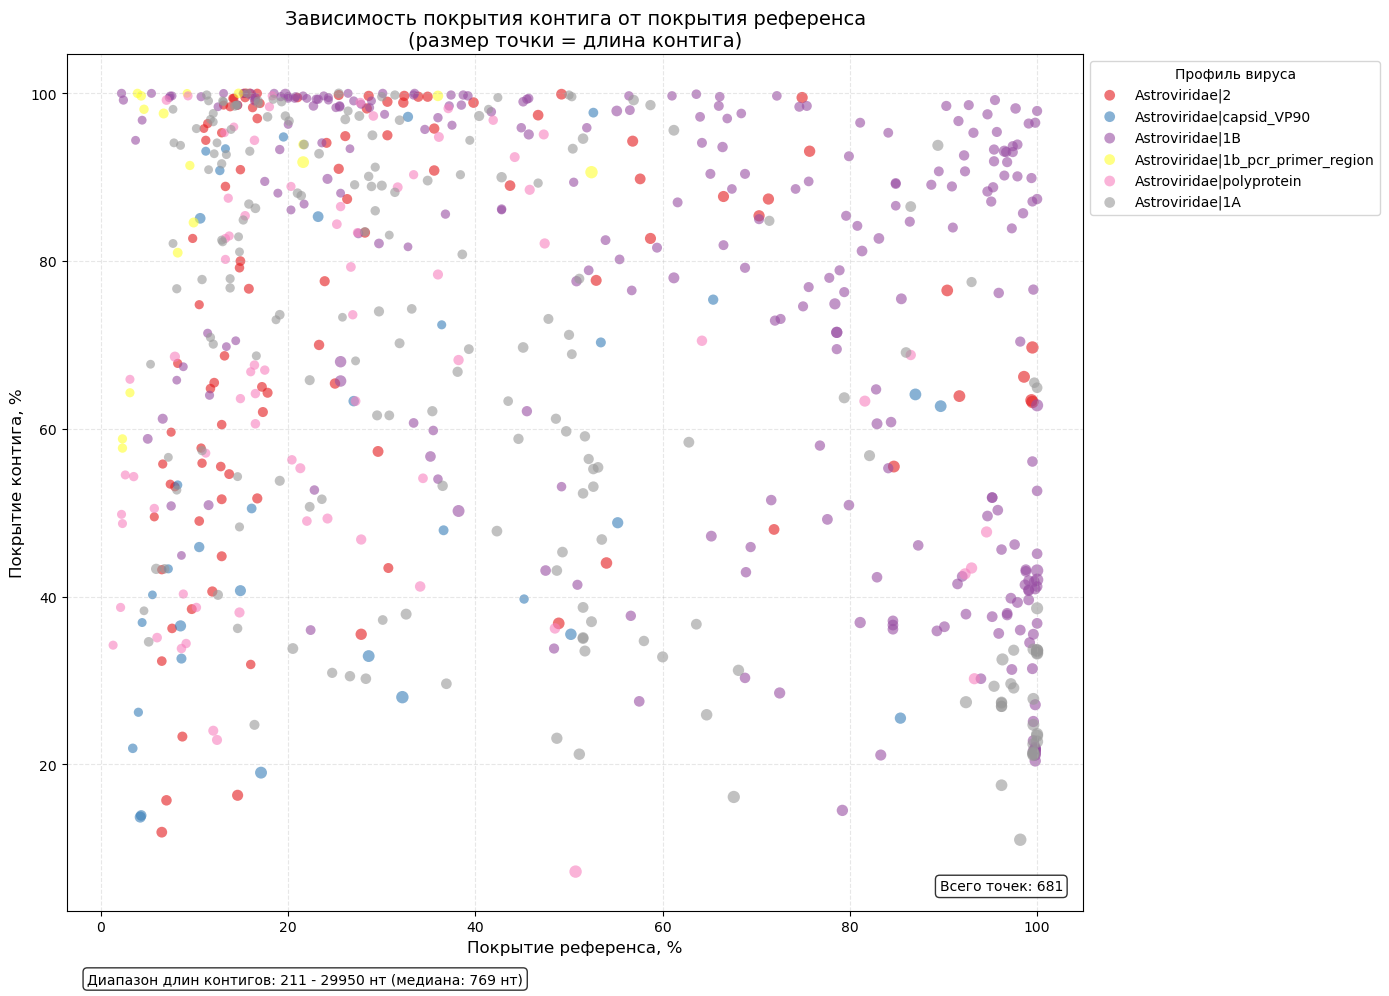


Summary statistics by virus profile:

Astroviridae|2:
  Number of contigs: 102
  Reference coverage: 29.0% (min: 5.7%, max: 99.5%)
  Contig coverage: 74.4% (min: 11.9%, max: 100.0%)
  Contig length: 967 nt (median: 587 nt)

Astroviridae|capsid_VP90:
  Number of contigs: 35
  Reference coverage: 28.1% (min: 3.4%, max: 89.7%)
  Contig coverage: 53.7% (min: 13.7%, max: 97.7%)
  Contig length: 623 nt (median: 509 nt)

Astroviridae|1B:
  Number of contigs: 267
  Reference coverage: 63.1% (min: 2.2%, max: 100.0%)
  Contig coverage: 73.7% (min: 14.5%, max: 100.0%)
  Contig length: 2186 nt (median: 1389 nt)

Astroviridae|1b_pcr_primer_region:
  Number of contigs: 16
  Reference coverage: 13.1% (min: 2.3%, max: 52.4%)
  Contig coverage: 88.1% (min: 57.7%, max: 100.0%)
  Contig length: 573 nt (median: 360 nt)

Astroviridae|polyprotein:
  Number of contigs: 72
  Reference coverage: 27.1% (min: 1.3%, max: 94.6%)
  Contig coverage: 66.3% (min: 7.2%, max: 99.7%)
  Contig length: 825 nt (median: 441

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
try:
    df = pd.read_csv('all_calculated_samples_results.tsv', sep='\t', encoding='utf-8')
except FileNotFoundError:
    print("Error: File not found. Please check the path.")
    exit()

# Convert columns to numeric
df['Покрытие референса, %'] = pd.to_numeric(df['Покрытие референса, %'], errors='coerce')
df['Покрытие контига, %'] = pd.to_numeric(df['Покрытие контига, %'], errors='coerce')
df['Длина контига, нт'] = pd.to_numeric(df['Длина контига, нт'], errors='coerce')

# Remove rows with missing values
df_clean = df.dropna(subset=['Покрытие референса, %', 'Покрытие контига, %', 'Длина контига, нт'])

if df_clean.empty:
    print("Error: No valid data after cleaning.")
    exit()

# Filter for specific virus profiles
# Create a list of profiles we want to keep
profiles_to_keep = ['Astroviridae']

# Filter the dataframe
# Using .str.contains() to match profiles that contain these names (case-sensitive)
# We'll use a more flexible approach: check if any of the profiles_to_keep are in the 'Профиль' column
mask = df_clean['Профиль'].str.contains('|'.join(profiles_to_keep), na=False)
df_filtered = df_clean[mask].copy()

print(f"Total points in full dataset: {len(df_clean)}")
print(f"Points after filtering for {', '.join(profiles_to_keep)}: {len(df_filtered)}")

if df_filtered.empty:
    print("No data found for the specified virus profiles.")
    print("Available profiles in the dataset:")
    print(df_clean['Профиль'].value_counts().head(20))
    exit()

# Create color mapping for different virus profiles
unique_profiles = df_filtered['Профиль'].unique()
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_profiles)))
profile_to_color = {profile: colors[i] for i, profile in enumerate(unique_profiles)}

# Create the plot
fig, ax = plt.subplots(figsize=(14, 10))

# For each virus profile, plot points with different color
for profile in unique_profiles:
    profile_data = df_filtered[df_filtered['Профиль'] == profile]
    
    # Log scale for size
    sizes = np.log1p(profile_data['Длина контига, нт'])
    sizes_scaled = 40 + (sizes - sizes.min()) / (sizes.max() - sizes.min()) * 40 if sizes.max() != sizes.min() else np.full_like(sizes, 25)
    
    plt.scatter(
        profile_data['Покрытие референса, %'],
        profile_data['Покрытие контига, %'],
        s=sizes_scaled,
        alpha=0.6,
        c=[profile_to_color[profile]],
        edgecolors='none',
        label=profile
    )

plt.xlabel('Покрытие референса, %', fontsize=12)
plt.ylabel('Покрытие контига, %', fontsize=12)
plt.title('Зависимость покрытия контига от покрытия референса\n(размер точки = длина контига)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)

# Add legend
plt.legend(title='Профиль вируса', loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Add size legend information
min_len = df_filtered['Длина контига, нт'].min()
max_len = df_filtered['Длина контига, нт'].max()
median_len = df_filtered['Длина контига, нт'].median()

# Create a small size legend manually
from matplotlib.patches import Circle

# Add example points to show size variation
example_sizes = [20, 50, 100]  # Small, medium, large point sizes
example_lengths = [min_len, median_len, max_len]

# We need to calculate what size corresponds to these lengths
# Reverse the scaling: size = 10 + (log(length) - log(min)) / (log(max) - log(min)) * 40
log_lengths = np.log1p(example_lengths)
log_min = np.log1p(min_len)
log_max = np.log1p(max_len)
if log_max != log_min:
    example_sizes_calc = 10 + (log_lengths - log_min) / (log_max - log_min) * 40
else:
    example_sizes_calc = [25, 25, 25]

# Add size legend at the bottom
size_legend_y = -0.15
for i, (size, length) in enumerate(zip(example_sizes_calc, example_lengths)):
    ax.scatter([], [], s=size, c='blue', alpha=0.6, label=f'{length:.0f} нт')
    
# Add text explanation
plt.text(0.02, -0.08, f'Диапазон длин контигов: {min_len:.0f} - {max_len:.0f} нт (медиана: {median_len:.0f} нт)',
         transform=ax.transAxes, ha='left', va='center', fontsize=10, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Show total points
plt.text(0.98, 0.02, f'Всего точек: {len(df_filtered)}', 
         transform=ax.transAxes, ha='right', va='bottom',
         fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print summary statistics for each profile
print("\n" + "="*60)
print("Summary statistics by virus profile:")
print("="*60)
for profile in unique_profiles:
    profile_data = df_filtered[df_filtered['Профиль'] == profile]
    print(f"\n{profile}:")
    print(f"  Number of contigs: {len(profile_data)}")
    print(f"  Reference coverage: {profile_data['Покрытие референса, %'].mean():.1f}% (min: {profile_data['Покрытие референса, %'].min():.1f}%, max: {profile_data['Покрытие референса, %'].max():.1f}%)")
    print(f"  Contig coverage: {profile_data['Покрытие контига, %'].mean():.1f}% (min: {profile_data['Покрытие контига, %'].min():.1f}%, max: {profile_data['Покрытие контига, %'].max():.1f}%)")
    print(f"  Contig length: {profile_data['Длина контига, нт'].mean():.0f} nt (median: {profile_data['Длина контига, нт'].median():.0f} nt)")

# Optionally save the plot
# plt.savefig('virus_coverage_scatter.png', dpi=300, bbox_inches='tight')

Total points in full dataset: 6961
Points after filtering for Astroviridae: 681


ImportError: cannot import name 'HandlerPatch' from 'matplotlib.legend' (c:\MALICHAVA\Tools\miniconda\envs\virus\Lib\site-packages\matplotlib\legend.py)

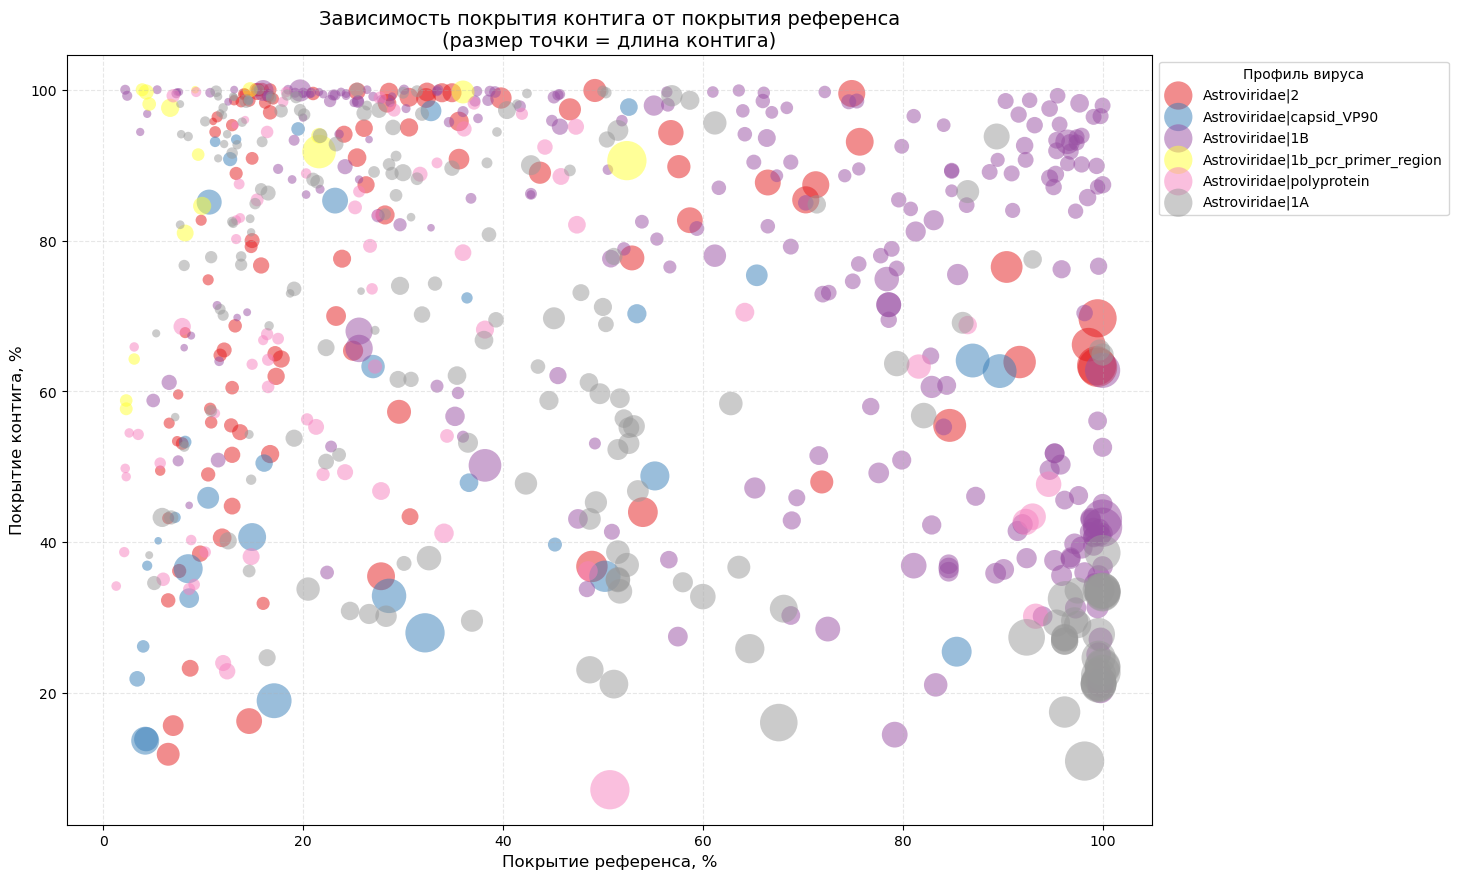

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
try:
    df = pd.read_csv('all_calculated_samples_results.tsv', sep='\t', encoding='utf-8')
except FileNotFoundError:
    print("Error: File not found. Please check the path.")
    exit()

# Convert columns to numeric
df['Покрытие референса, %'] = pd.to_numeric(df['Покрытие референса, %'], errors='coerce')
df['Покрытие контига, %'] = pd.to_numeric(df['Покрытие контига, %'], errors='coerce')
df['Длина контига, нт'] = pd.to_numeric(df['Длина контига, нт'], errors='coerce')

# Remove rows with missing values
df_clean = df.dropna(subset=['Покрытие референса, %', 'Покрытие контига, %', 'Длина контига, нт'])

if df_clean.empty:
    print("Error: No valid data after cleaning.")
    exit()

# Filter for specific virus profiles
profiles_to_keep = ['Astroviridae']

# Filter the dataframe
mask = df_clean['Профиль'].str.contains('|'.join(profiles_to_keep), na=False)
df_filtered = df_clean[mask].copy()

print(f"Total points in full dataset: {len(df_clean)}")
print(f"Points after filtering for {', '.join(profiles_to_keep)}: {len(df_filtered)}")

if df_filtered.empty:
    print("No data found for the specified virus profiles.")
    print("Available profiles in the dataset:")
    print(df_clean['Профиль'].value_counts().head(20))
    exit()

# Create color mapping for different virus profiles
unique_profiles = df_filtered['Профиль'].unique()
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_profiles)))
profile_to_color = {profile: colors[i] for i, profile in enumerate(unique_profiles)}

# Create the plot
fig, ax = plt.subplots(figsize=(14, 10))

# For each virus profile, plot points with different color
for profile in unique_profiles:
    profile_data = df_filtered[df_filtered['Профиль'] == profile]
    
    # Log scale for size with MUCH larger size range
    # Using square root transformation for more moderate size differences
    # Or we can use a power transformation to make differences more visible
    sizes = np.sqrt(profile_data['Длина контига, нт'])
    
    # Scale to a larger range: minimum size 30, maximum 800
    # This makes the size difference much more noticeable
    min_size = 30
    max_size = 800
    
    if sizes.max() != sizes.min():
        sizes_scaled = min_size + (sizes - sizes.min()) / (sizes.max() - sizes.min()) * (max_size - min_size)
    else:
        sizes_scaled = np.full_like(sizes, min_size + (max_size - min_size) / 2)
    
    plt.scatter(
        profile_data['Покрытие референса, %'],
        profile_data['Покрытие контига, %'],
        s=sizes_scaled,
        alpha=0.5,
        c=[profile_to_color[profile]],
        edgecolors='none',
        label=profile
    )

plt.xlabel('Покрытие референса, %', fontsize=12)
plt.ylabel('Покрытие контига, %', fontsize=12)
plt.title('Зависимость покрытия контига от покрытия референса\n(размер точки = длина контига)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)

# Add legend
plt.legend(title='Профиль вируса', loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Add size legend information
min_len = df_filtered['Длина контига, нт'].min()
max_len = df_filtered['Длина контига, нт'].max()
median_len = df_filtered['Длина контига, нт'].median()

# Create a clear size legend with actual circles
from matplotlib.patches import Circle

# Define example contig lengths (small, medium, large)
example_lengths = [min_len, median_len, max_len]

# Calculate the sizes for these lengths
example_sqrt = np.sqrt(example_lengths)
sqrt_min = np.sqrt(min_len)
sqrt_max = np.sqrt(max_len)
min_size = 30
max_size = 800

if sqrt_max != sqrt_min:
    example_sizes_calc = min_size + (example_sqrt - sqrt_min) / (sqrt_max - sqrt_min) * (max_size - min_size)
else:
    example_sizes_calc = [min_size + (max_size - min_size) / 2] * 3

# Create a custom legend for sizes
from matplotlib.legend import HandlerPatch

# Create a small inset axes for size legend
size_legend_ax = plt.axes([0.02, 0.02, 0.25, 0.08], frameon=True)
size_legend_ax.set_xlim(0, 1)
size_legend_ax.set_ylim(0, 1)
size_legend_ax.axis('off')

# Add circles of different sizes
positions = [0.15, 0.5, 0.85]
labels = [f'{int(length)} нт' for length in example_lengths]

for pos, size, label in zip(positions, example_sizes_calc, labels):
    # Scale the size for display in the legend (make them a bit larger for visibility)
    display_size = size * 0.3
    circle = Circle((pos, 0.5), radius=np.sqrt(display_size)/2, color='blue', alpha=0.5)
    size_legend_ax.add_patch(circle)
    size_legend_ax.text(pos, 0.15, label, ha='center', va='center', fontsize=8)

size_legend_ax.text(0.5, 0.85, 'Длина контига', ha='center', va='center', fontsize=9, fontweight='bold')

# Alternative: Use the main plot for size legend
# Add example points on the main plot with labels
legend_elements = []
for length, size in zip(example_lengths, example_sizes_calc):
    # Create a legend entry with a circle of appropriate size
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                      markerfacecolor='blue', markersize=np.sqrt(size)/2,
                                      alpha=0.6, label=f'{int(length)} нт'))

# Add the size legend to the main plot
# Place it in the lower right corner
size_legend = plt.legend(handles=legend_elements, title='Длина контига', 
                         loc='lower right', fontsize=9, 
                         bbox_to_anchor=(0.98, 0.02), 
                         framealpha=0.9)

# Add the main legend back
plt.gca().add_artist(size_legend)

# Add text explanation about size scaling
plt.text(0.02, -0.08, f'Диапазон длин контигов: {min_len:.0f} - {max_len:.0f} нт (медиана: {median_len:.0f} нт)',
         transform=ax.transAxes, ha='left', va='center', fontsize=10, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Show total points
plt.text(0.98, 0.98, f'Всего точек: {len(df_filtered)}', 
         transform=ax.transAxes, ha='right', va='top',
         fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print summary statistics for each profile
print("\n" + "="*60)
print("Summary statistics by virus profile:")
print("="*60)
for profile in unique_profiles:
    profile_data = df_filtered[df_filtered['Профиль'] == profile]
    print(f"\n{profile}:")
    print(f"  Number of contigs: {len(profile_data)}")
    print(f"  Reference coverage: {profile_data['Покрытие референса, %'].mean():.1f}% (min: {profile_data['Покрытие референса, %'].min():.1f}%, max: {profile_data['Покрытие референса, %'].max():.1f}%)")
    print(f"  Contig coverage: {profile_data['Покрытие контига, %'].mean():.1f}% (min: {profile_data['Покрытие контига, %'].min():.1f}%, max: {profile_data['Покрытие контига, %'].max():.1f}%)")
    print(f"  Contig length: {profile_data['Длина контига, нт'].mean():.0f} nt (median: {profile_data['Длина контига, нт'].median():.0f} nt)")

# Optionally save the plot
# plt.savefig('virus_coverage_scatter.png', dpi=300, bbox_inches='tight')